# StatCompare

Python port of the
[`StatCompare`](https://github.com/HMU-WH/ggcompare/blob/main/vignettes/StatCompare.Rmd)
vignette from the R package
[ggcompare](https://github.com/HMU-WH/ggcompare).

The `stat_compare` layer in `plotnine_extra` improves on
[`ggsignif::geom_signif()`](https://github.com/const-ae/ggsignif)
and
[`ggpubr::stat_compare_means()`](https://github.com/kassambara/ggpubr)
in three ways:

1. **Stable adaptation to faceting** — per-panel detection of
   the x-positions that actually contain data.
2. **Layer-level p-value adjustment** across panels (vs
   ggpubr's panel-level only), toggled by `panel_indep`.
3. **Smoothly handles missing groupings** inside individual
   panels.

You usually don't need to specify a test method. Just tell
`stat_compare` whether you want a parametric or
non-parametric test via the `parametric` flag, and the layer
picks the right one:

| number of groups | parametric | non-parametric |
| --- | --- | --- |
| 2 | Welch t-test | Wilcoxon rank-sum test |
| > 2 | One-way ANOVA | Kruskal-Wallis test |


In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib

matplotlib.rcParams["figure.dpi"] = 110

from plotnine import (
    aes,
    after_stat,
    element_text,
    facet_grid,
    geom_boxplot,
    ggplot,
    theme,
    theme_bw,
)
from plotnine.data import mpg

import plotnine_extra
from plotnine_extra import stat_compare

print("plotnine_extra", plotnine_extra.__version__)
mpg.head()

plotnine_extra 0.2.0


,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


## Basic

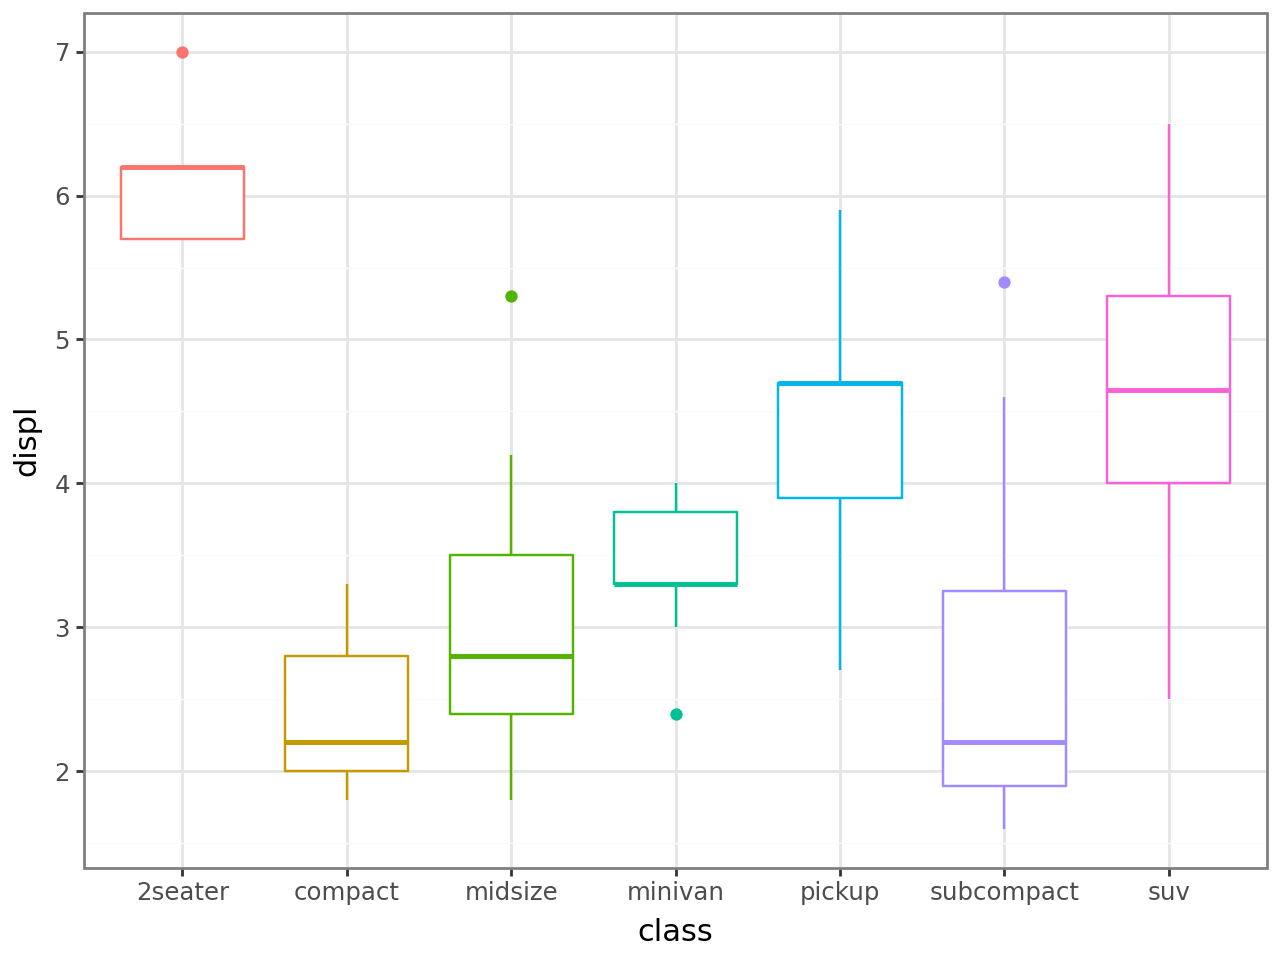

In [2]:
p = (
    ggplot(mpg, aes("class", "displ", color="class"))
    + geom_boxplot(show_legend=False)
    + theme_bw()
)
p

**Global comparison** — each x has only one group, so a single Kruskal-Wallis test is run across all classes.

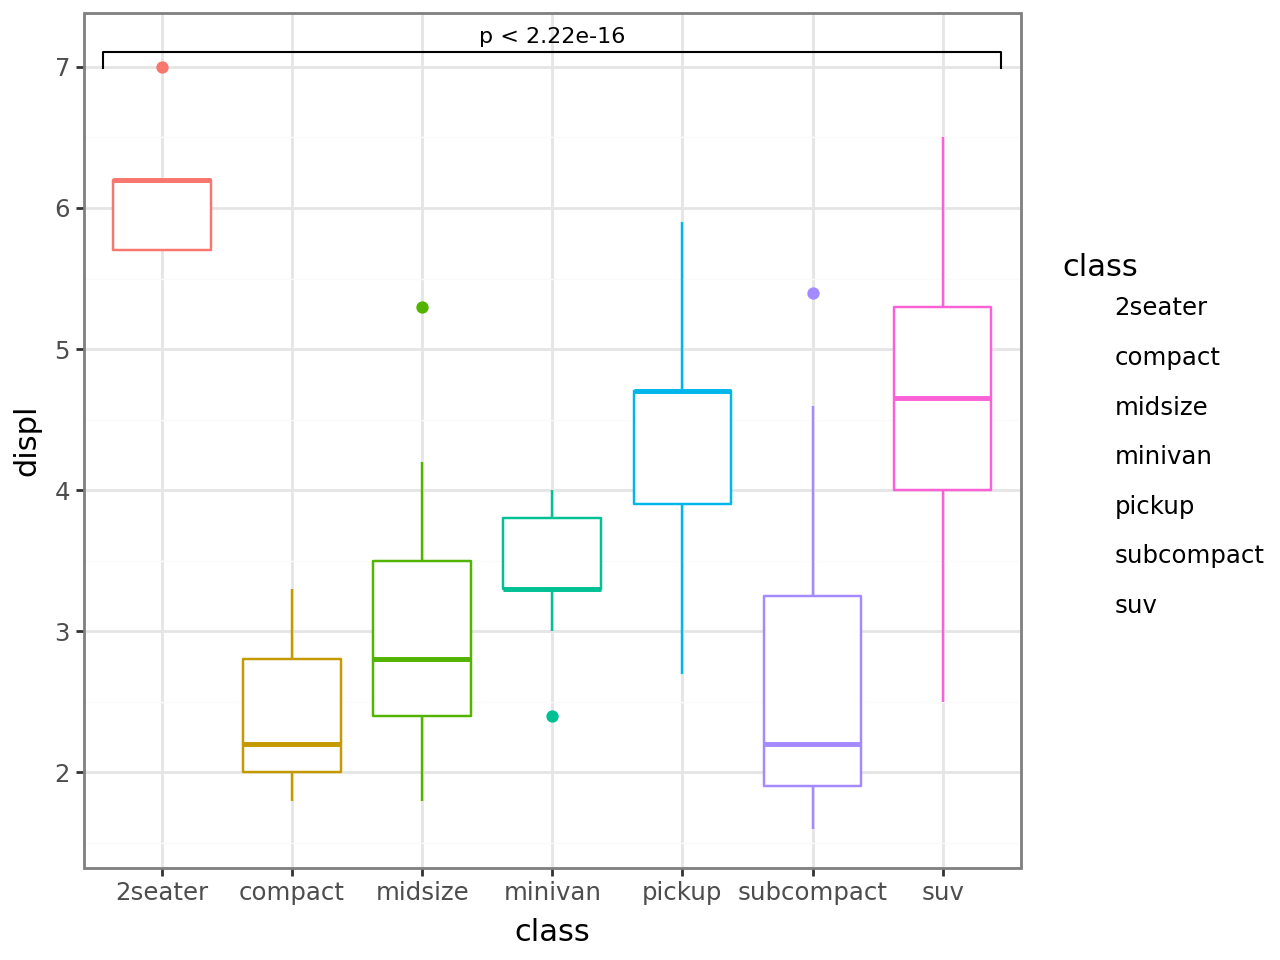

In [3]:
p + stat_compare()

If you only want the p-value text without the bracket, set `bracket=False`.

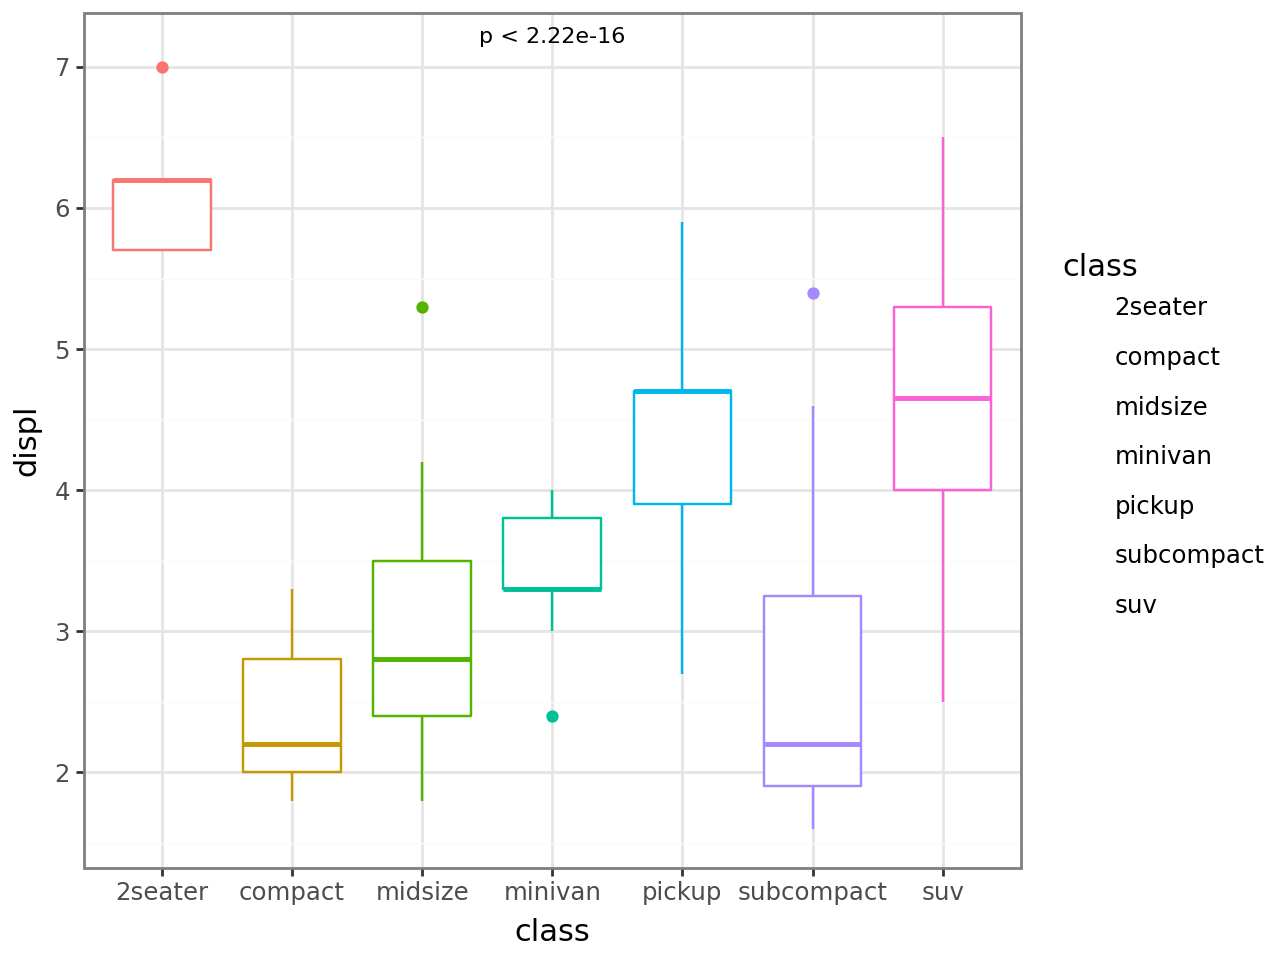

In [4]:
p + stat_compare(bracket=False)

Display the test method by mapping `label` from the computed `method` and `label` aesthetics.

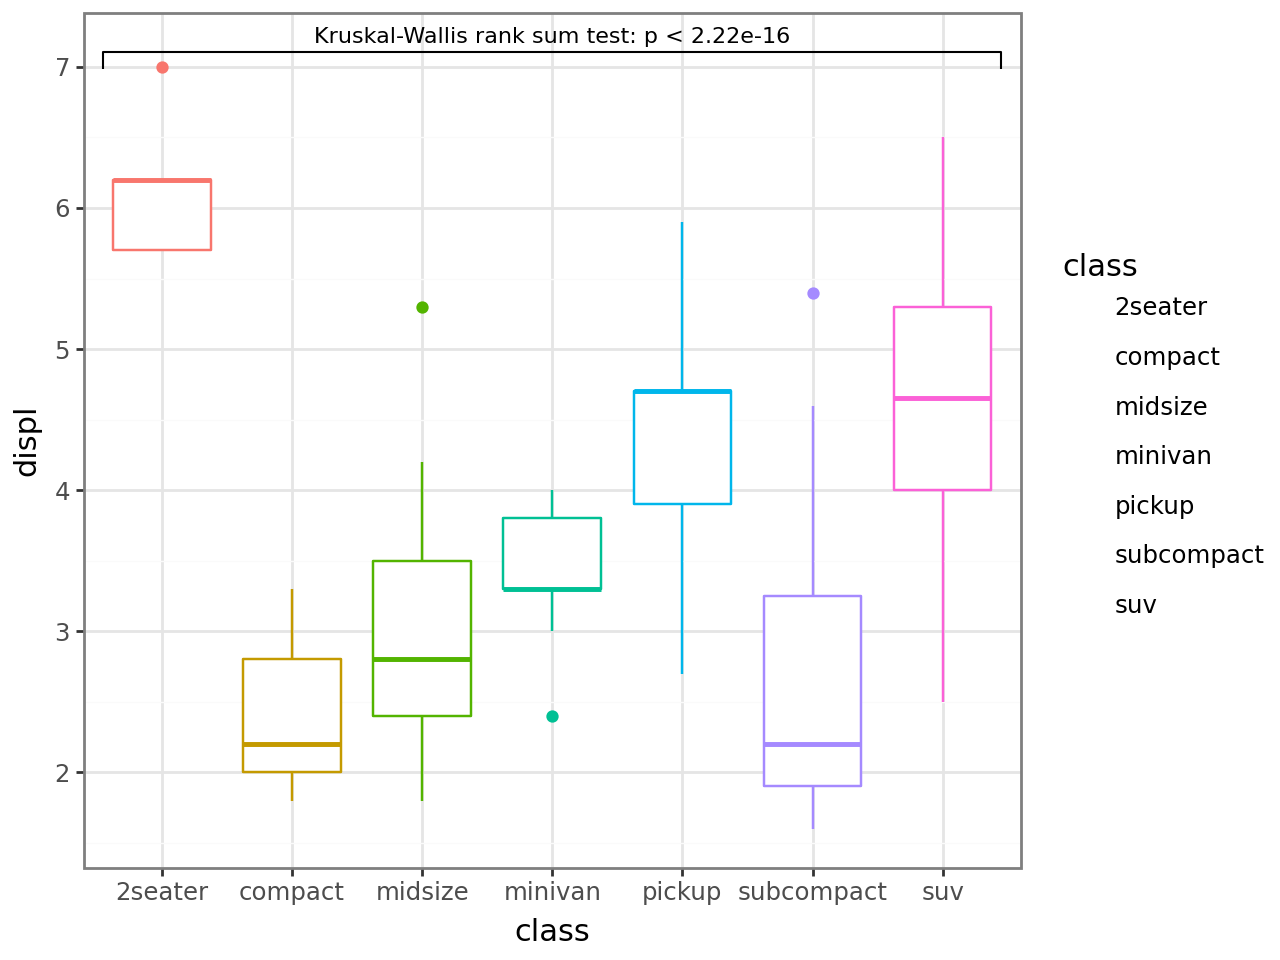

In [5]:
p + stat_compare(
    aes(
        label=after_stat(
            'method.astype(str) + ": " + label.astype(str)'
        )
    )
)

**Each group vs. the rest** — `overall=True` compares each x against the union of all other x-axis groups.

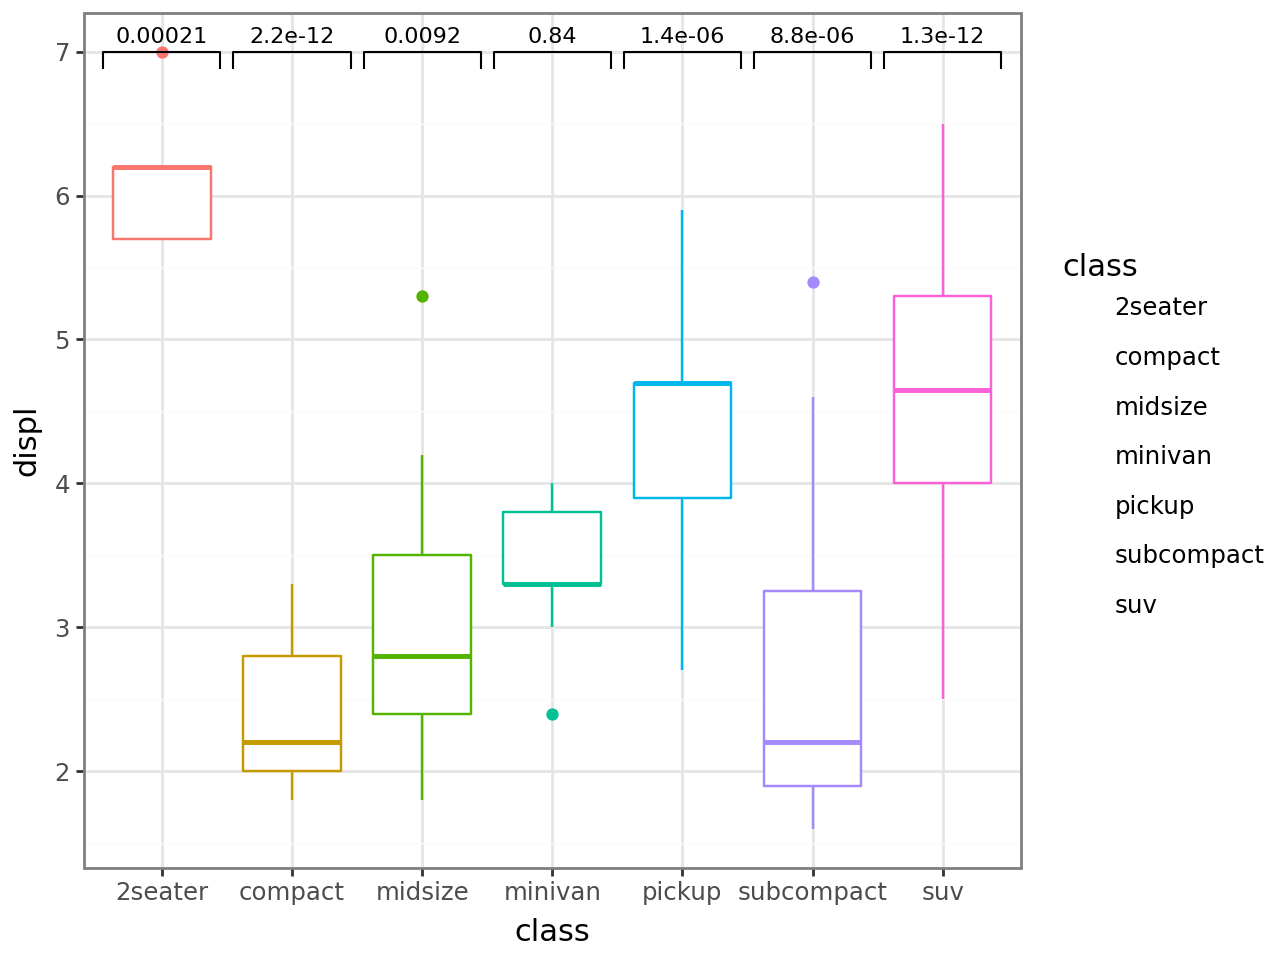

In [6]:
p + stat_compare(overall=True)

**Reference group** — every other x-axis level is compared against the reference level.

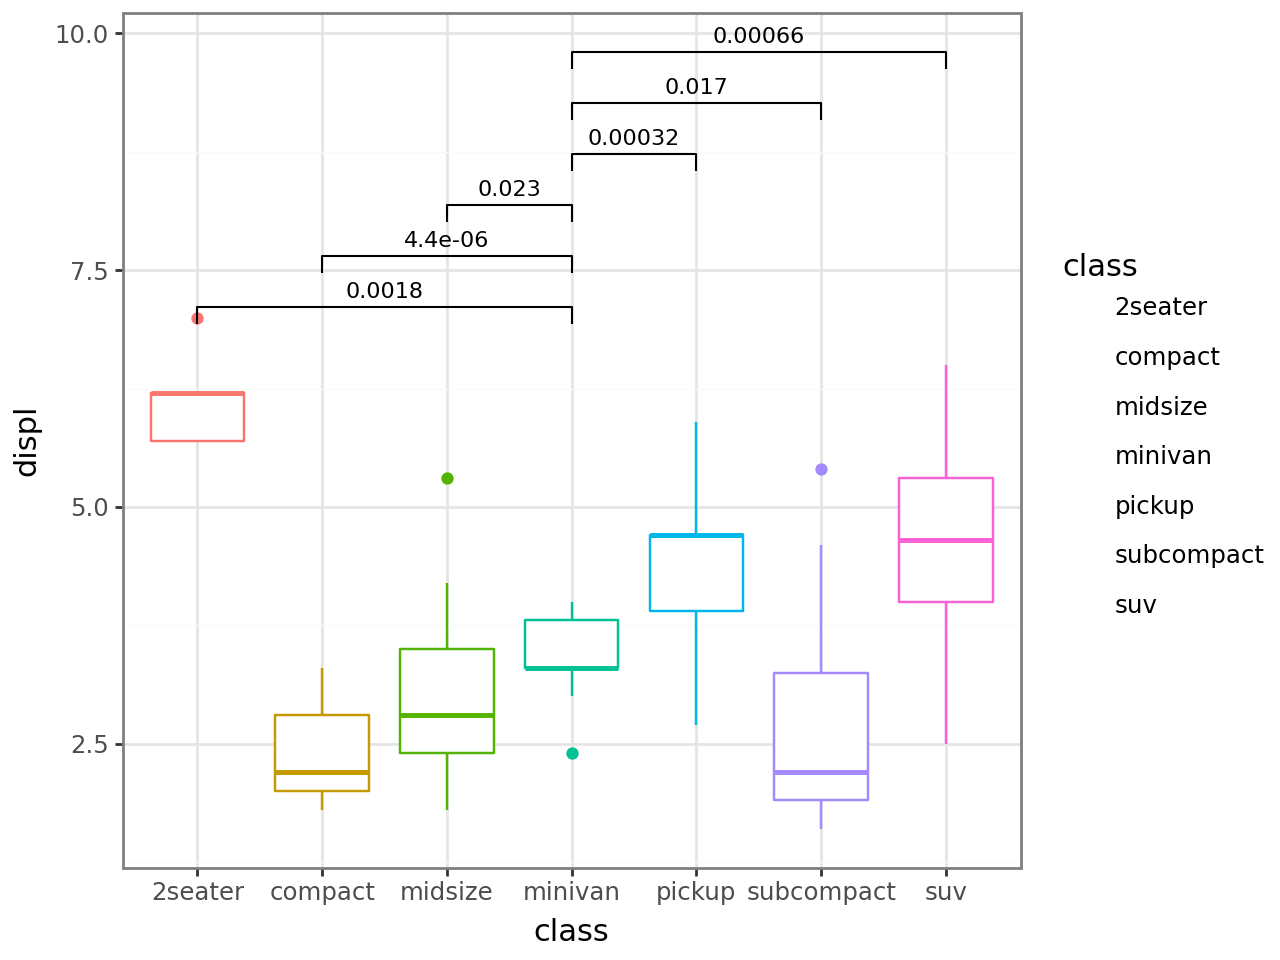

In [7]:
p + stat_compare(ref_group="minivan")

Hide labels for non-significant comparisons via `cutoff`.

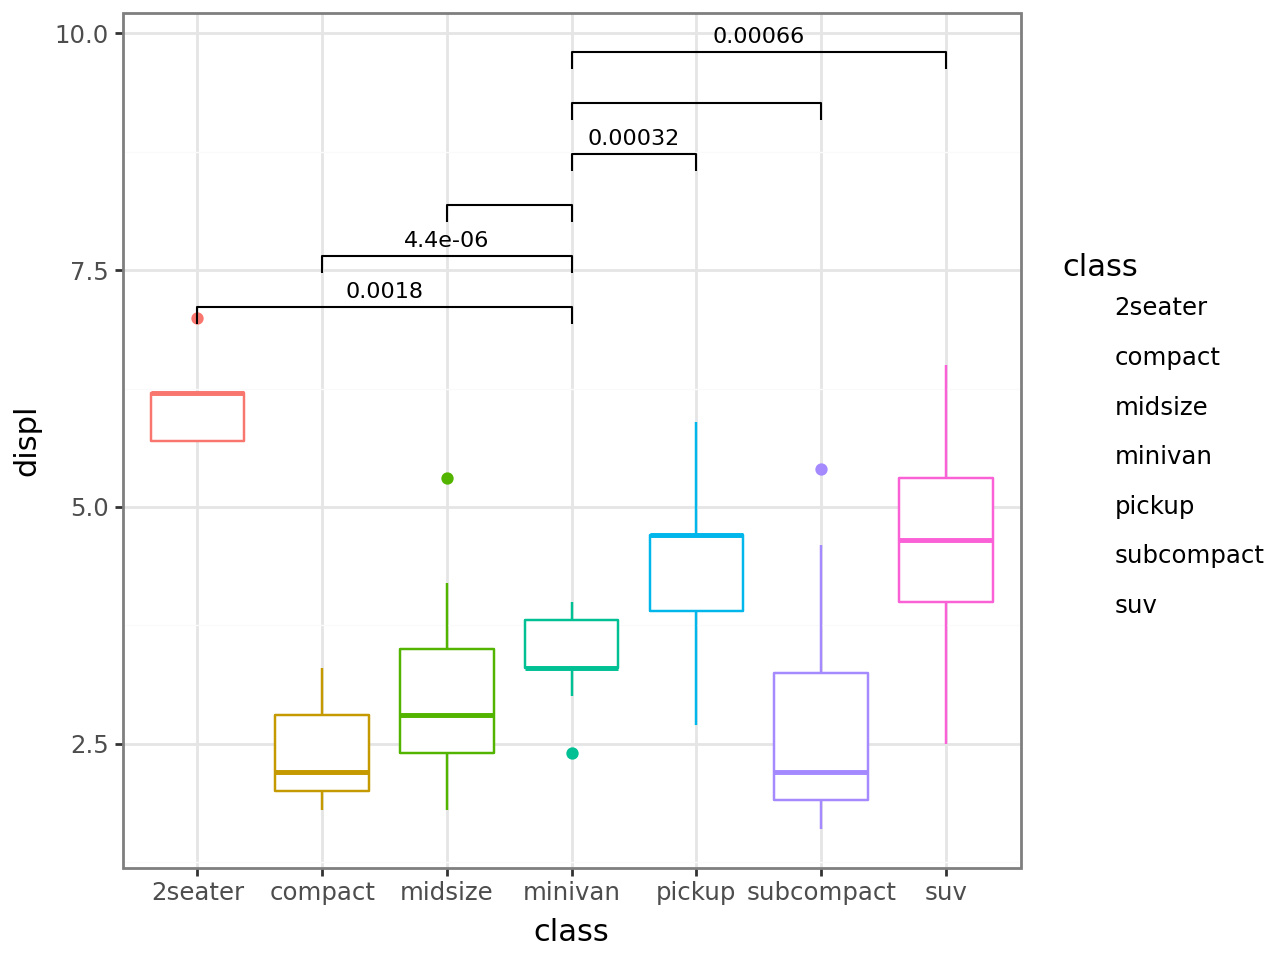

In [8]:
p + stat_compare(ref_group="minivan", cutoff=0.01)

Display significance symbols by passing the `breaks`.

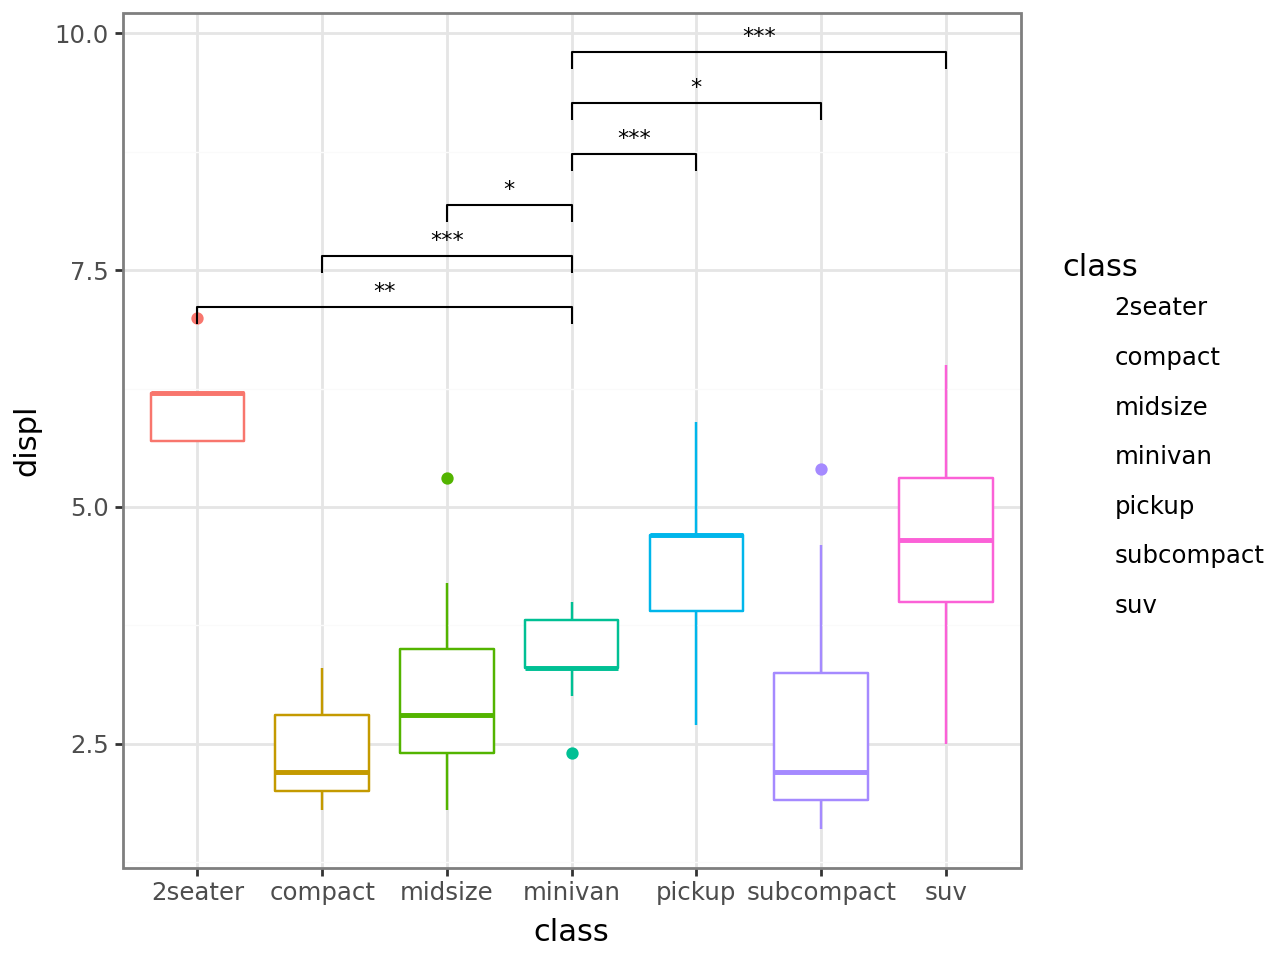

In [9]:
p + stat_compare(
    ref_group="minivan",
    breaks=[0, 0.001, 0.01, 0.05, 1],
)

**Explicit comparisons** — pass a list of pairs.

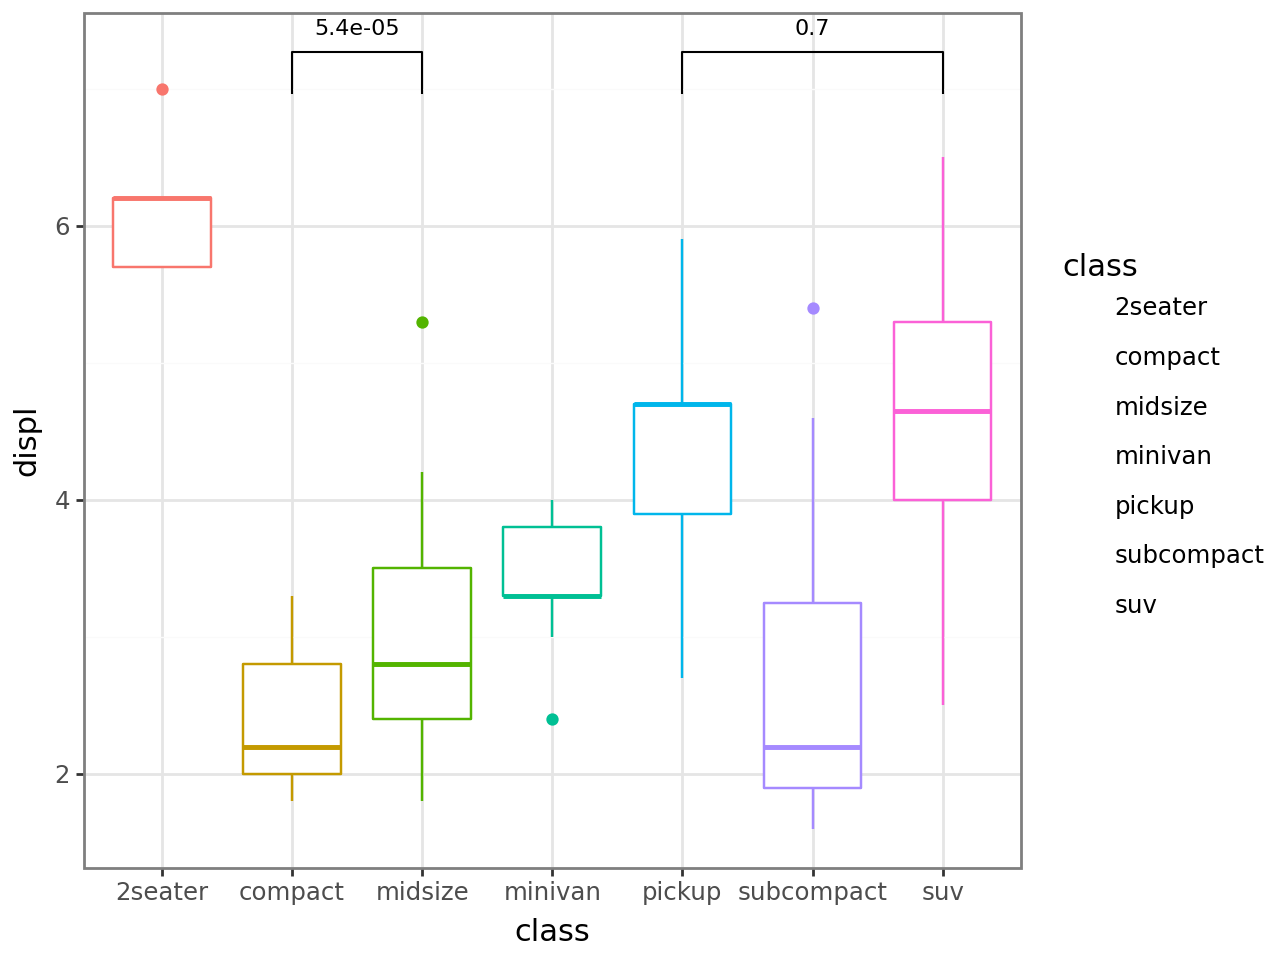

In [10]:
p + stat_compare(
    tip_length=0.05,
    step_increase=0,
    comparisons=[
        ("compact", "midsize"),
        ("pickup", "suv"),
    ],
)

**Within-x population comparison** — when boxes are dodged within each x by another aesthetic, `stat_compare` automatically tests groups within each x. A second `stat_compare(group=...)` layer adds the global comparison on top.

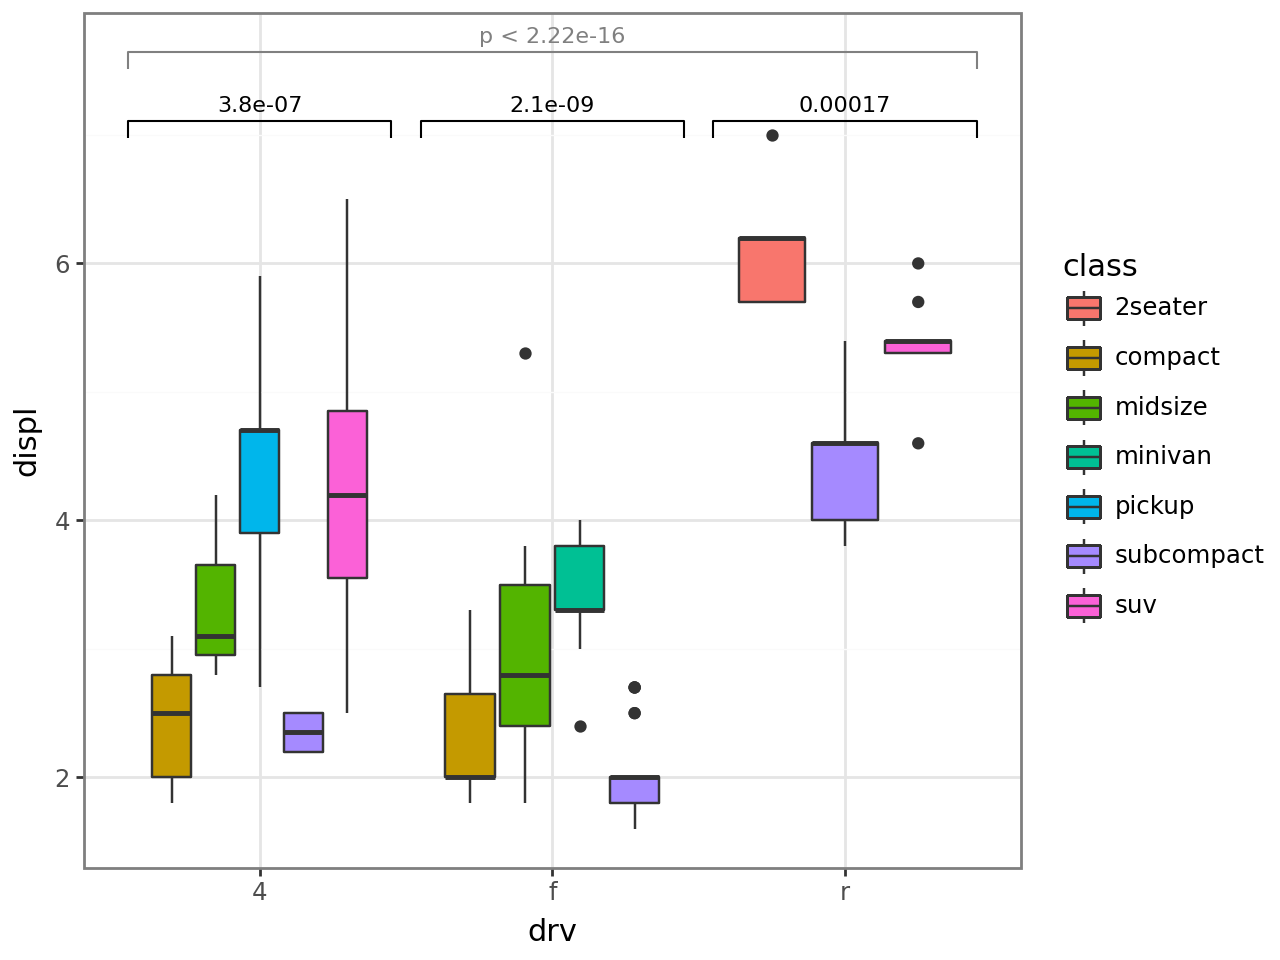

In [11]:
(
    ggplot(mpg, aes("drv", "displ", fill="class"))
    + geom_boxplot()
    + stat_compare()
    + stat_compare(aes(group="drv"), nudge=0.1, color="gray")
    + theme_bw()
)

## Enhancements

### Better adaptation to faceting

Pass an explicit comparison list and let `stat_compare` apply it across each panel, even when some panels are missing one of the groups.

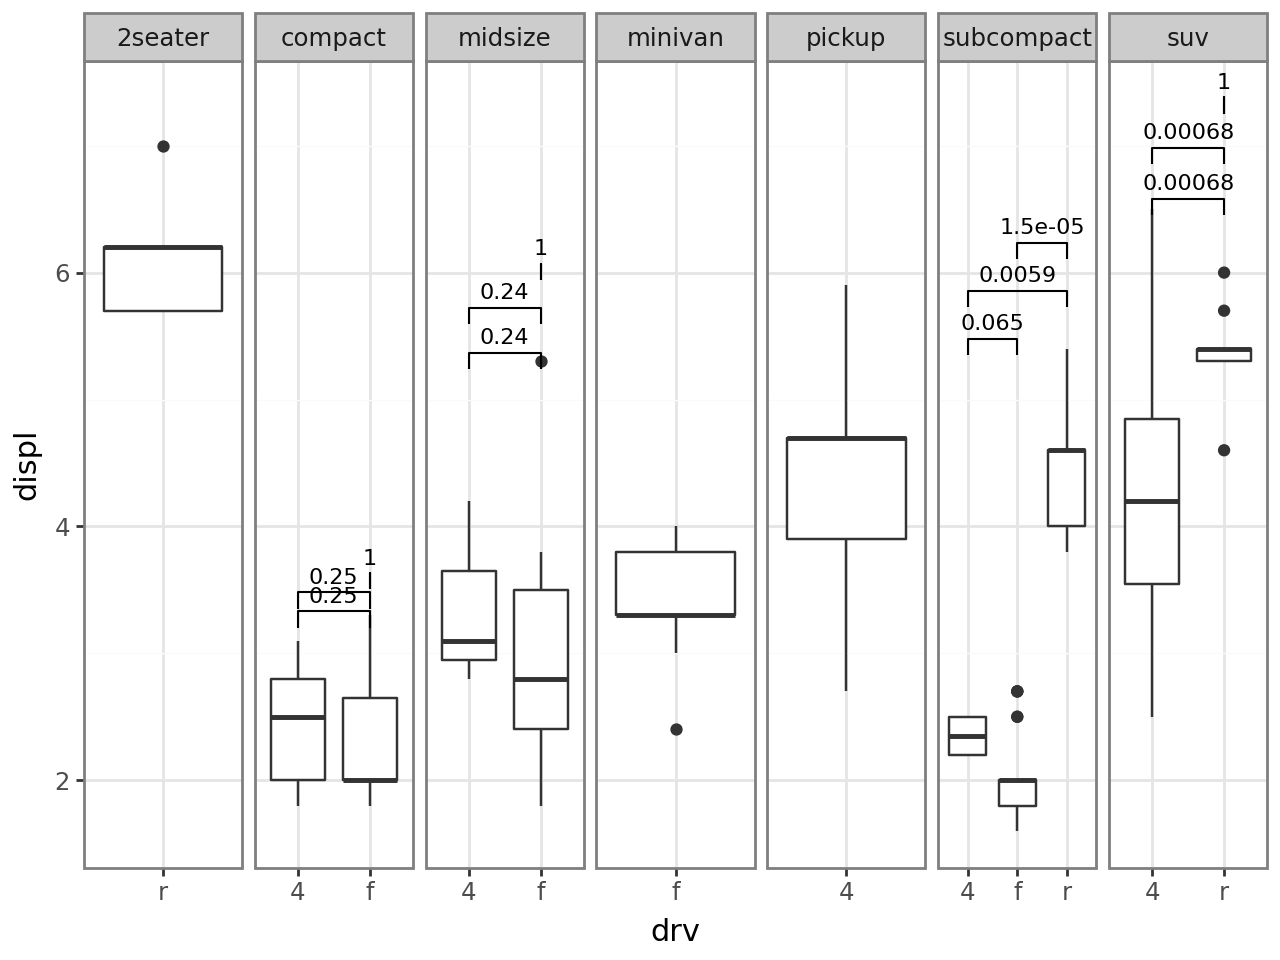

In [12]:
from itertools import combinations

drv_levels = sorted(mpg["drv"].unique())
pairs = list(combinations(drv_levels, 2))

(
    ggplot(mpg, aes("drv", "displ"))
    + geom_boxplot()
    + stat_compare(comparisons=pairs)
    + facet_grid(cols="class", scales="free")
    + theme_bw()
)

### P-value correction

By default, when `correction != "none"`, `stat_compare` adjusts p-values across **the entire layer** (including every panel). Set `panel_indep=True` to fall back on panel-only adjustment, the way ggpubr does.

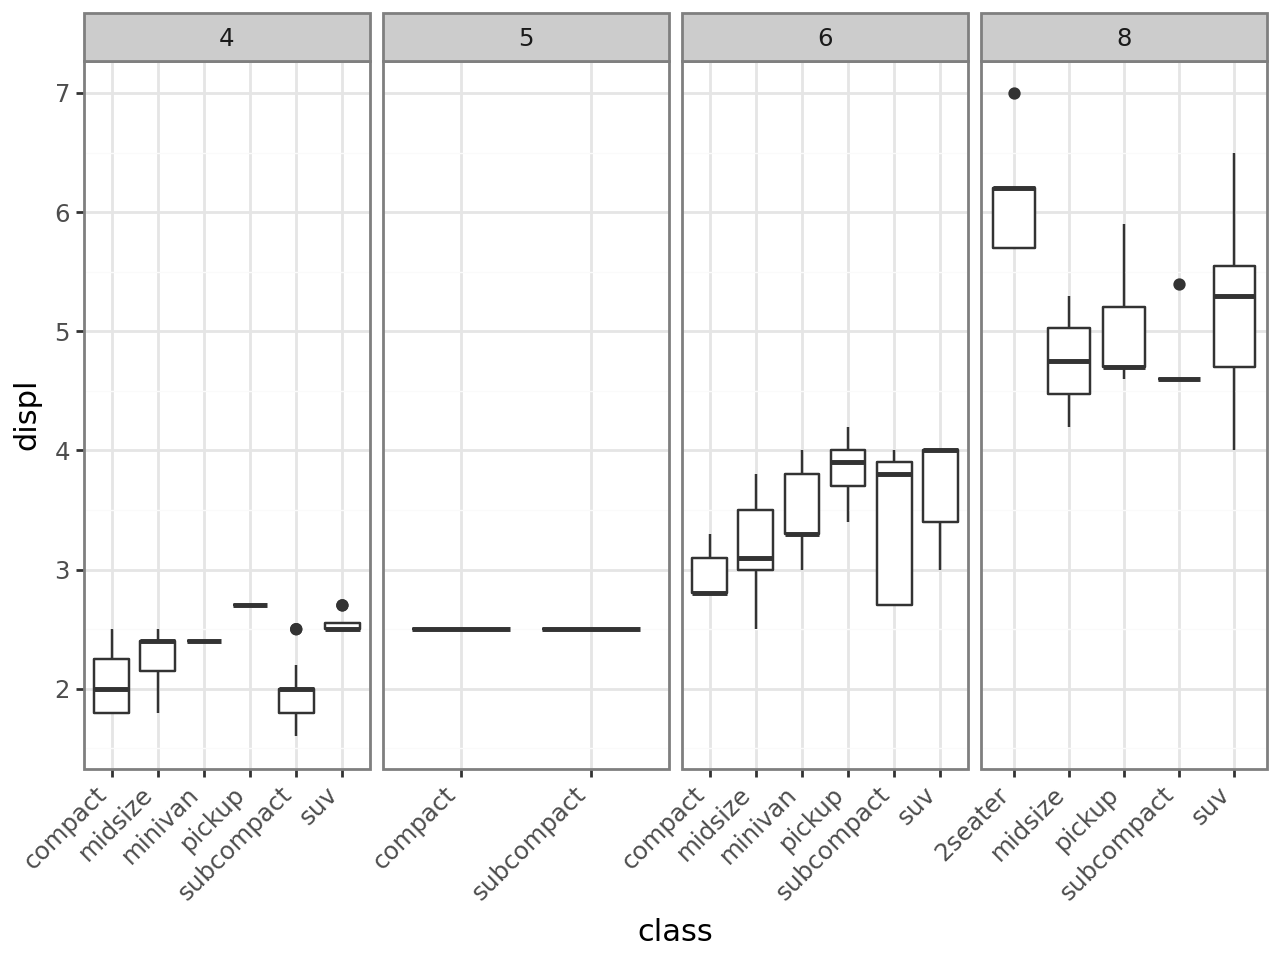

In [13]:
base = (
    ggplot(mpg, aes("class", "displ"))
    + geom_boxplot()
    + facet_grid(cols="cyl", scales="free")
    + theme_bw()
    + theme(axis_text_x=element_text(rotation=45, ha="right"))
)
base

**Layer-level FDR correction**

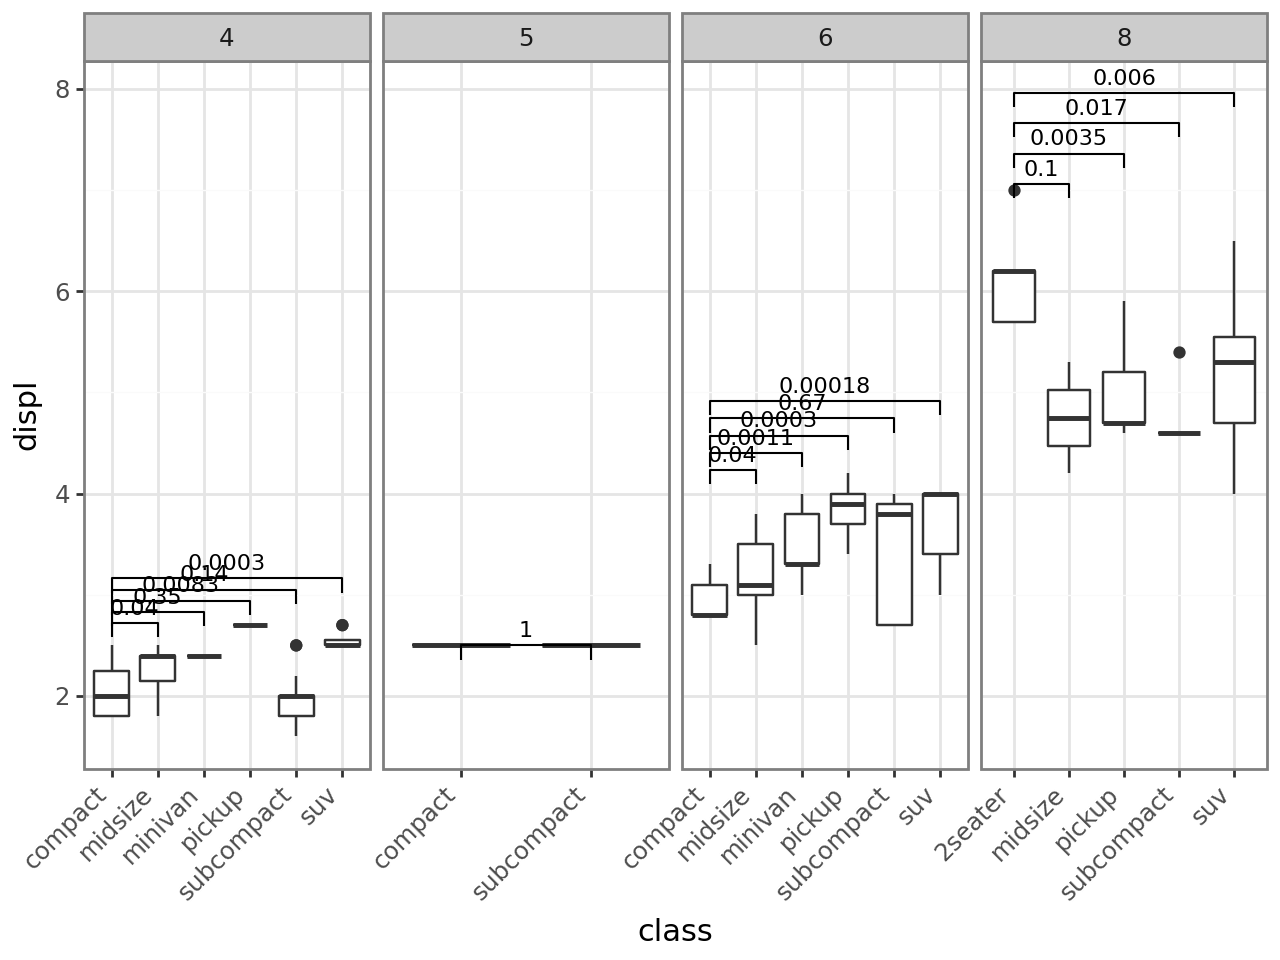

In [14]:
base + stat_compare(ref_group=1, correction="fdr")

**Panel-level FDR correction**

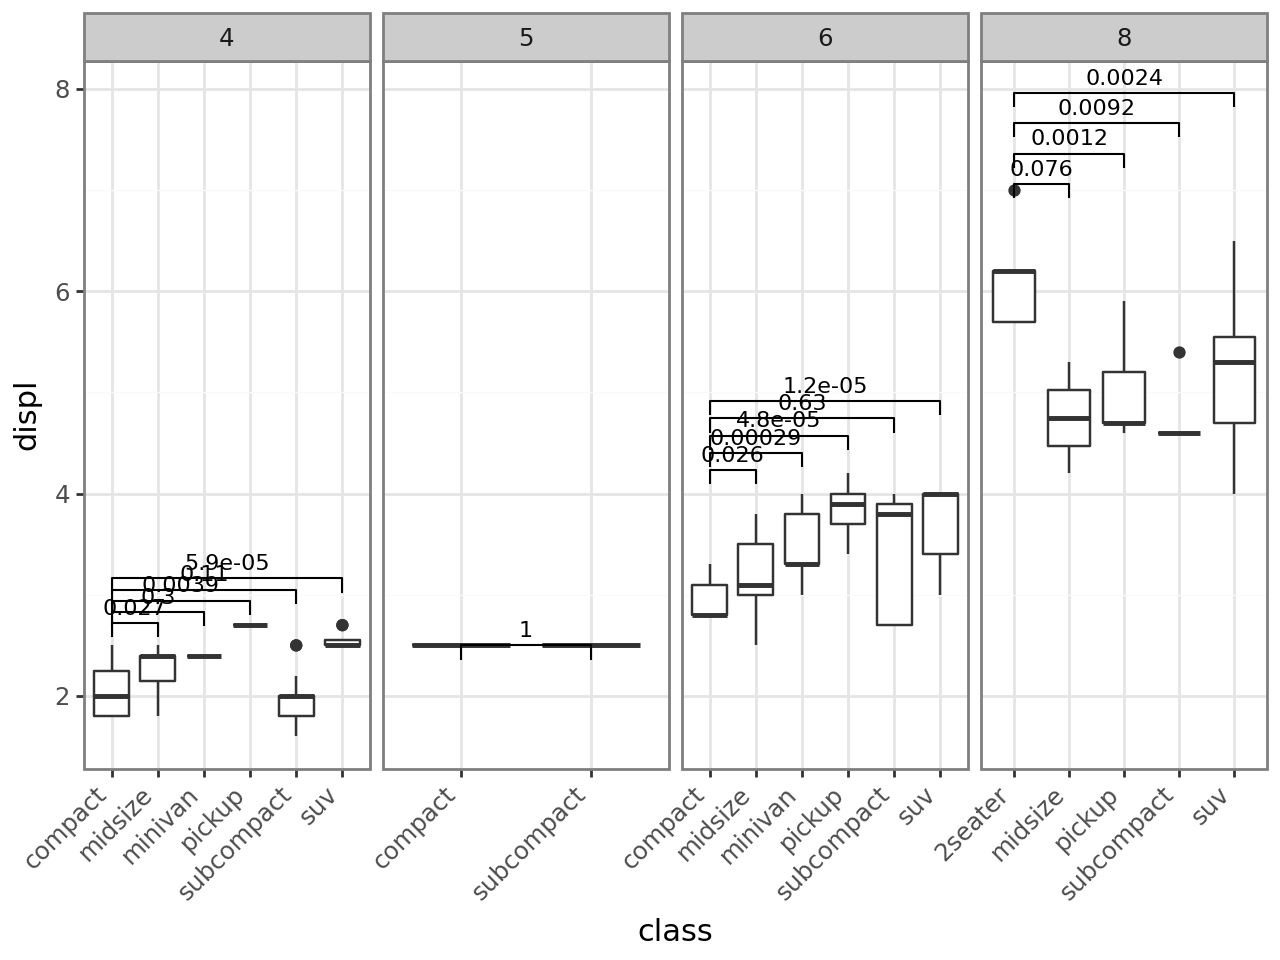

In [15]:
base + stat_compare(
    ref_group=1, correction="fdr", panel_indep=True
)

## Notes on the Python port

* The default `geom` is `geom_bracket` (already shipped with `plotnine_extra`).
* For ggcompare's `arrow=` parameter we instead expose `bracket=False` to suppress the bracket and draw only the label. Arrow rendering on the bracket tips is left for a future release.
* `correction` accepts the same names as R's `p.adjust.methods`: `none`, `bonferroni`, `holm`, `hochberg`, `hommel`, `BH`/`fdr`, `BY`.
* `method` accepts a callable returning a scipy `HypothesisResult`-like object (anything with a `.pvalue` attribute), so you can plug in custom tests.